# Temporal Fusion Transformer (No Wavelets)

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
!pip install lightning

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import torch
import lightning.pytorch as pl

# verify Kaggle sees both T4s
print(torch.cuda.device_count(), [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])

1 ['NVIDIA GeForce RTX 4050 Laptop GPU']


In [9]:
# Ensure TFT dependencies are available in the notebook runtime.
import importlib.util
import subprocess
import sys

required_packages = {
    "torch": "torch",
    "lightning": "lightning",
    "pytorch_forecasting": "pytorch-forecasting",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

# Import libraries used for data prep, TFT training, and evaluation.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42, workers=True)
np.random.seed(42)
torch.manual_seed(42)


Seed set to 42


In [12]:
# Load data and reproduce the earlier notebook cleanup pipeline.
df = pd.read_csv("../../total_consumption_data.csv")
df.columns = [c.strip() for c in df.columns]

if np.issubdtype(df["datetime"].dtype, np.number):
    df["datetime"] = pd.to_datetime(df["datetime"], unit="s", errors="coerce")
else:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

for col in df.columns:
    if col not in ["datetime", "meter_id"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(["meter_id", "datetime"]).reset_index(drop=True)

# Impute missing values meter-wise with forward/backward fill (LOCF style).
num_cols = [c for c in df.columns if c not in ["datetime", "meter_id"]]
df[num_cols] = df.groupby("meter_id")[num_cols].ffill()
df[num_cols] = df.groupby("meter_id")[num_cols].bfill()

# Drop structurally redundant or unused phase-2/phase-3 and duplicate aggregate channels.
drop_cols = [
    "aenergy_ph2", "aenergy_ph3", "renergy_ph2", "renergy_ph3",
    "apower_ph2", "apower_ph3", "rpower_ph2", "rpower_ph3",
    "current_ph2", "current_ph3", "pfactor_ph2", "pfactor_ph3",
    "voltage_ph2", "voltage_ph3", "apower", "pfactor",
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# Remove numeric columns that are fully zero after cleanup.
num_cols = [c for c in df.columns if c not in ["datetime", "meter_id"]]
zero_cols = [c for c in num_cols if np.isclose(df[c].fillna(0).abs().sum(), 0)]
if zero_cols:
    df = df.drop(columns=zero_cols)

# Create compact static category labels expected by TFT.
meter_ids = sorted(df["meter_id"].dropna().unique().tolist())
meter_map = {m: f"M{i:03d}" for i, m in enumerate(meter_ids)}
df["meter_label"] = df["meter_id"].map(meter_map).fillna("UNK")

df = df.dropna(subset=["datetime", "meter_id"]).copy()
df.head()


,datetime,meter_id,aenergy,aenergy_ph1,renergy,renergy_ph1,apower_ph1,rpower_ph1,current_ph1,pfactor_ph1,voltage_ph1,meter_label
0,2019-08-27 22:00:05,00124B0018D6F607,4.0,19830.0,0.0,4765.0,242.0,-30.0,1.3,0.9,223.0,M000
1,2019-08-27 22:01:05,00124B0018D6F607,4.0,19834.0,0.0,4765.0,287.0,-32.0,1.4,0.9,223.0,M000
2,2019-08-27 22:02:05,00124B0018D6F607,11.0,19845.0,0.0,4765.0,1354.0,-34.0,6.1,1.0,221.0,M000
3,2019-08-27 22:03:05,00124B0018D6F607,22.0,19867.0,0.0,4765.0,1390.0,-36.0,6.2,1.0,223.0,M000
4,2019-08-27 22:04:05,00124B0018D6F607,24.0,19891.0,0.0,4765.0,1401.0,-36.0,6.3,1.0,222.0,M000


In [13]:
# Build the same engineered feature set used in earlier notebooks (without PCA/wavelets).
df_fe = df.copy()

df_fe["apparent_power_ph1"] = df_fe["voltage_ph1"] * df_fe["current_ph1"]
df_fe["pf_angle_ph1"] = np.arccos(np.clip(df_fe["pfactor_ph1"], -1, 1))
df_fe["energy_intensity"] = df_fe["aenergy_ph1"] / (df_fe["apparent_power_ph1"].abs() + 1e-6)
df_fe["Q_P_ratio"] = df_fe["rpower_ph1"] / (df_fe["apower_ph1"].abs() + 1e-6)

df_fe["hour"] = df_fe["datetime"].dt.hour.astype("int16")
df_fe["dayofweek"] = df_fe["datetime"].dt.dayofweek.astype("int16")
df_fe["is_weekend"] = (df_fe["dayofweek"] >= 5).astype("int8")
df_fe["is_peak"] = df_fe["hour"].between(8, 20).astype("int8")

# Add short-term local power context as a rolling feature.
df_fe["apower_roll3"] = (
    df_fe.groupby("meter_id")["apower_ph1"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

feature_cols = [
    "aenergy", "aenergy_ph1", "renergy", "renergy_ph1",
    "apower_ph1", "rpower_ph1", "current_ph1", "pfactor_ph1", "voltage_ph1",
    "apparent_power_ph1", "pf_angle_ph1", "energy_intensity", "Q_P_ratio",
    "hour", "dayofweek", "is_weekend", "is_peak", "apower_roll3",
]
feature_cols = [c for c in feature_cols if c in df_fe.columns]

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
df_fe[feature_cols] = df_fe[feature_cols].fillna(df_fe[feature_cols].median(numeric_only=True))

target_col = "apower_ph1"

# Enforce finite numeric values before creating TimeSeriesDataSet tensors.
for col in set(feature_cols + [target_col]):
    df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce")
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
df_fe = df_fe.dropna(subset=[target_col]).copy()
df_fe[feature_cols] = df_fe[feature_cols].fillna(df_fe[feature_cols].median(numeric_only=True))
df_fe = df_fe.dropna(subset=feature_cols).copy()

# Create per-meter sequential indices for temporal modeling.
df_fe = df_fe.sort_values(["meter_id", "datetime"]).reset_index(drop=True)
df_fe["time_idx"] = df_fe.groupby("meter_id").cumcount()

# Keep only meters with enough history for encoder + prediction windows.
max_encoder_length = 24
max_prediction_length = 1
min_len = max_encoder_length + max_prediction_length + 1
valid_meters = df_fe.groupby("meter_id").size()
valid_meters = valid_meters[valid_meters >= min_len].index
df_fe = df_fe[df_fe["meter_id"].isin(valid_meters)].copy()

df_fe[["datetime", "meter_id", "time_idx", target_col]].head()


,datetime,meter_id,time_idx,apower_ph1
0,2019-08-27 22:00:05,00124B0018D6F607,0,242.0
1,2019-08-27 22:01:05,00124B0018D6F607,1,287.0
2,2019-08-27 22:02:05,00124B0018D6F607,2,1354.0
3,2019-08-27 22:03:05,00124B0018D6F607,3,1390.0
4,2019-08-27 22:04:05,00124B0018D6F607,4,1401.0


In [14]:
# Split each meter timeline into train/validation/test ranges to avoid temporal leakage.
group_max_idx = df_fe.groupby("meter_id")["time_idx"].max()
train_cutoffs = (group_max_idx * 0.70).astype(int)
val_cutoffs = (group_max_idx * 0.85).astype(int)

df_fe["train_cutoff"] = df_fe["meter_id"].map(train_cutoffs)
df_fe["val_cutoff"] = df_fe["meter_id"].map(val_cutoffs)

train_df = df_fe[df_fe["time_idx"] <= df_fe["train_cutoff"]].copy()
val_df = df_fe[df_fe["time_idx"] <= df_fe["val_cutoff"]].copy()
test_df = df_fe.copy()

known_reals = ["time_idx", "hour", "dayofweek", "is_weekend", "is_peak"]
unknown_reals = [c for c in feature_cols if c not in known_reals]
if target_col not in unknown_reals:
    unknown_reals = [target_col] + unknown_reals

# Define TFT datasets with learned normalizers and sequence settings.
training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target=target_col,
    group_ids=["meter_id"],
    static_categoricals=["meter_label"],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    target_normalizer=GroupNormalizer(groups=["meter_id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, val_df, stop_randomization=True)
testing = TimeSeriesDataSet.from_dataset(training, test_df, stop_randomization=True)

batch_size = 128
train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=256 * 2, num_workers=0)
test_loader = testing.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print(f"Train windows: {len(training):,}")
print(f"Validation windows: {len(validation):,}")
print(f"Test windows: {len(testing):,}")


Train windows: 100,977
Validation windows: 122,615
Test windows: 144,256


In [18]:
# Configure and train an end-to-end Temporal Fusion Transformer.
accelerator = "gpu" if torch.cuda.is_available() else "cpu"

early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, mode="min")

trainer = pl.Trainer(
    max_epochs=15,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop],
    enable_model_summary=True,
    enable_checkpointing=True,
    logger=False,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=3,
)

print(f"Trainable parameters: {tft.size() / 1e3:.1f}k")
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_ckpt = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
best_ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Trainable parameters: 115.5k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     24 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    736 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.9 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 44.9 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 11.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 115 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 115 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 595                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=15` reached.


'/kaggle/working/checkpoints/epoch=14-step=11820.ckpt'

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note tha

,MAE,RMSE,R2,MAPE(%)
Validation,82.0108,264.2549,0.8680,26.4444
Test,79.1865,259.4437,0.8649,27.0478


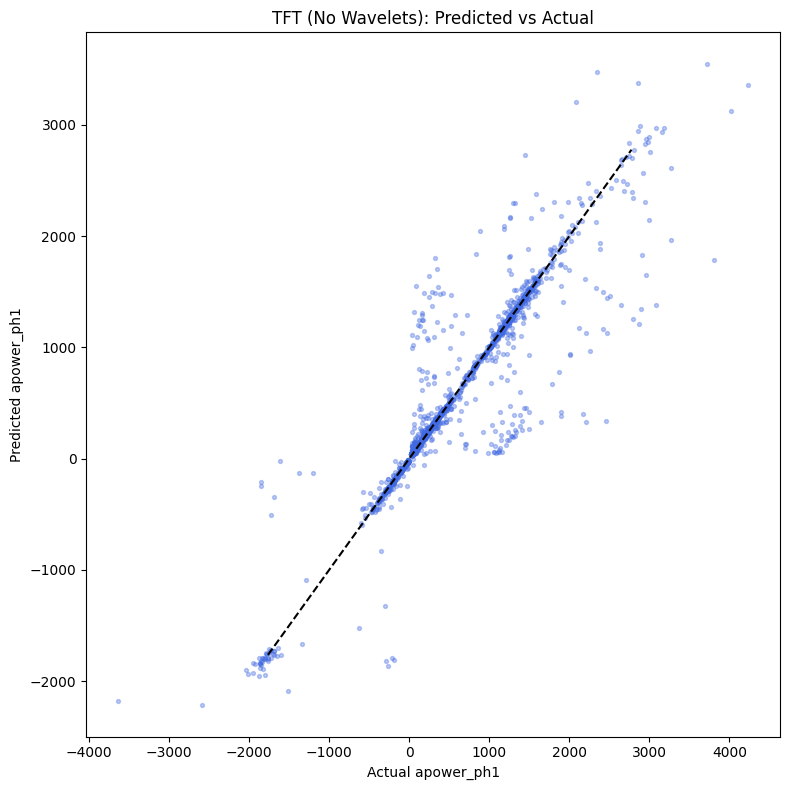

In [22]:
# Evaluate point forecasts on validation and test windows.
def collect_targets(dataloader):
    y_true = []
    for _, y in dataloader:
        target = y[0] if isinstance(y, (tuple, list)) else y
        y_true.append(target.detach().cpu())
    return torch.cat(y_true, dim=0).numpy().reshape(-1)

def collect_predictions(model, dataloader):
    preds = model.predict(
        dataloader, 
        mode="prediction", 
        trainer_kwargs=dict(accelerator="gpu" if torch.cuda.is_available() else "cpu")
    )
    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()
    return np.array(preds).reshape(-1)

def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6)).mean()) * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE(%)": mape}

val_true = collect_targets(val_loader)
val_pred = collect_predictions(best_tft, val_loader)

test_true = collect_targets(test_loader)
test_pred = collect_predictions(best_tft, test_loader)

metrics_df = pd.DataFrame(
    {
        "Validation": regression_metrics(val_true, val_pred),
        "Test": regression_metrics(test_true, test_pred),
    }
).T
display(metrics_df.round(4))

# Plot predicted vs actual values for a random test subset.
sample_n = min(3000, len(test_true))
idx = np.random.choice(len(test_true), size=sample_n, replace=False)

plt.figure(figsize=(8, 8))
plt.scatter(test_true[idx], test_pred[idx], s=8, alpha=0.35, color="royalblue")
diag_min, diag_max = np.percentile(test_true, [1, 99])
plt.plot([diag_min, diag_max], [diag_min, diag_max], "k--", lw=1.5)
plt.xlabel("Actual apower_ph1")
plt.ylabel("Predicted apower_ph1")
plt.title("TFT (No Wavelets): Predicted vs Actual")
plt.tight_layout()
plt.show()


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x700 with 1 Axes>,
 'decoder_variables': <Figure size 700x350 with 1 Axes>}

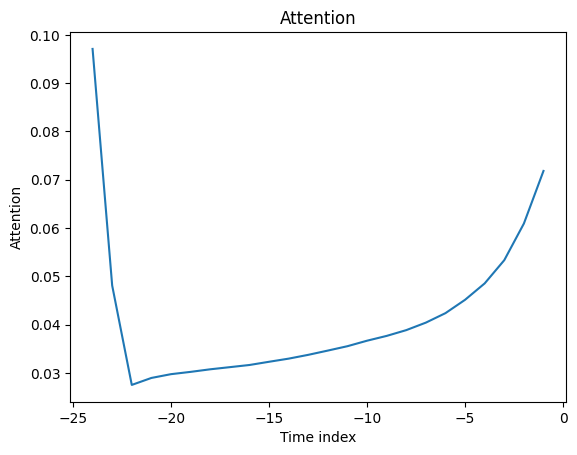

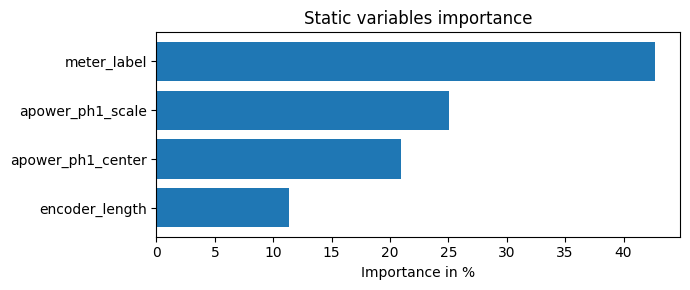

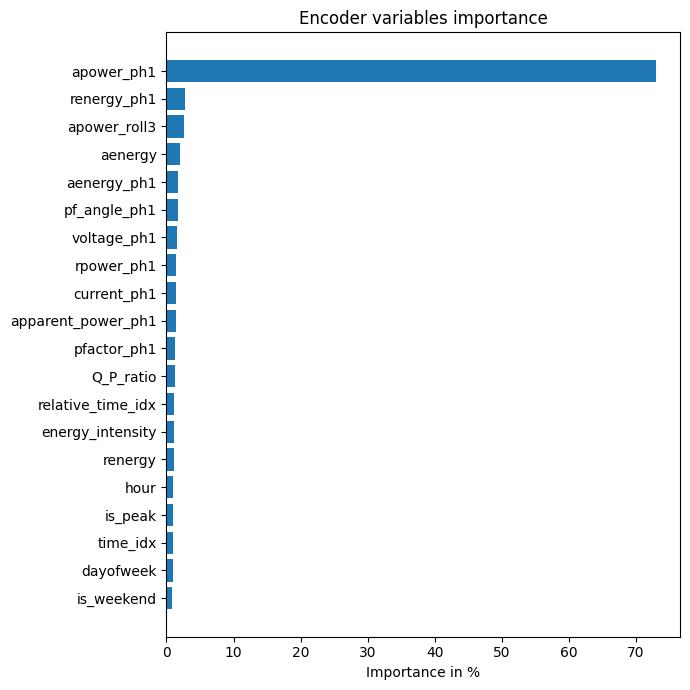

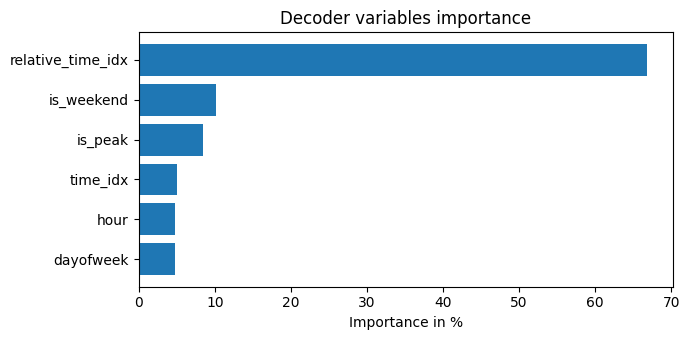

In [27]:
# Inspect learned temporal/feature importance and save artifacts.
predict_output = best_tft.predict(
    val_loader, 
    mode="raw", 
    return_x=True,
    trainer_kwargs=dict(accelerator="gpu" if torch.cuda.is_available() else "cpu")
)
# Depending on the pytorch-forecasting version, predict might return a different length tuple.
# The first element is always the raw predictions, and the second is x
raw_preds, x = predict_output[0], predict_output[1]

interpretation = best_tft.interpret_output(raw_preds, reduction="sum")
best_tft.plot_interpretation(interpretation)

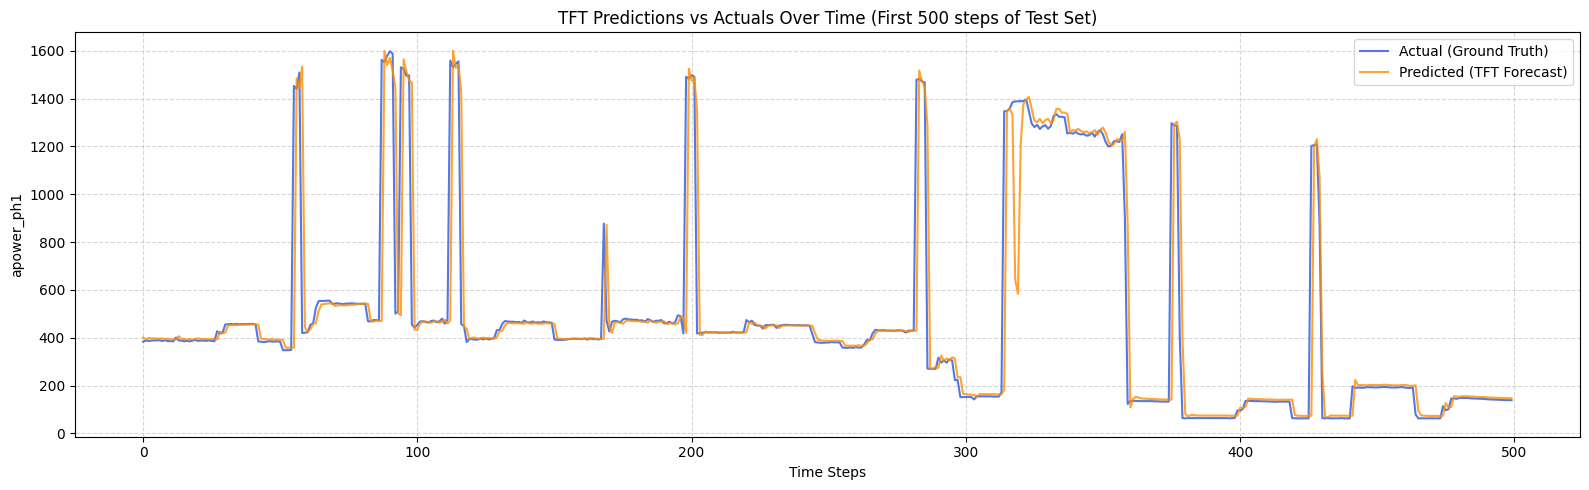

In [28]:
# Plot continuous actual vs predicted series over a specific time frame
time_frame = 500  # Number of initial test time steps to plot (e.g., first few days/weeks of the first meter)

plt.figure(figsize=(16, 5))
plt.plot(test_true[:time_frame], label="Actual (Ground Truth)", color="royalblue", alpha=0.9, lw=1.5)
plt.plot(test_pred[:time_frame], label="Predicted (TFT Forecast)", color="darkorange", alpha=0.8, lw=1.5)

plt.xlabel("Time Steps")
plt.ylabel("apower_ph1")
plt.title(f"TFT Predictions vs Actuals Over Time (First {time_frame} steps of Test Set)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [2]:
import shutil

src = "/kaggle/working/checkpoints/epoch=14-step=11820.ckpt"
dst = "/kaggle/working/epoch=14-step=11820.ckpt"

shutil.copy(src, dst)

shutil.copy(best_ckpt, "tft_no_wavelets.ckpt")
metrics_df.to_csv("tft_no_wavelets_metrics.csv", index=True)
print("Saved: tft_no_wavelets.ckpt, tft_no_wavelets_metrics.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/checkpoints/epoch=14-step=11820.ckpt'

In [30]:
import shutil

shutil.make_archive("/kaggle/working/checkpoint", 'zip', "/kaggle/working/checkpoints")

'/kaggle/working/checkpoint.zip'

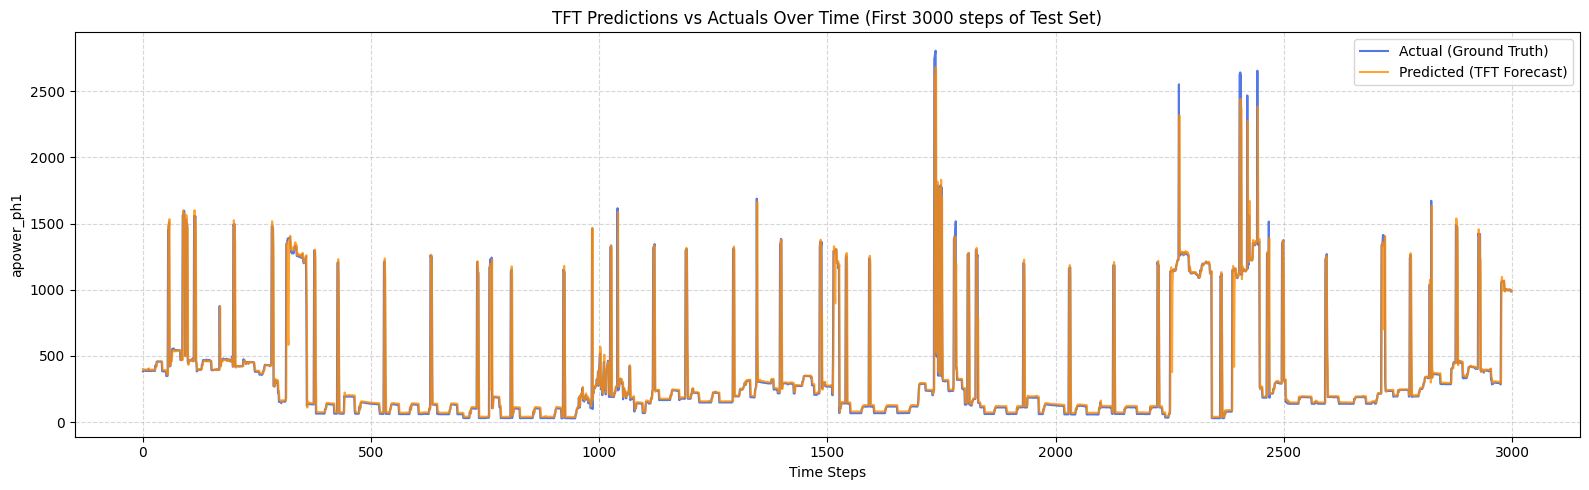

In [17]:
# Plot continuous actual vs predicted series over a specific time frame
time_frame = 3000  # Number of initial test time steps to plot (e.g., first few days/weeks of the first meter)

plt.figure(figsize=(16, 5))
plt.plot(test_true[:time_frame], label="Actual (Ground Truth)", color="royalblue", alpha=0.9, lw=1.5)
plt.plot(test_pred[:time_frame], label="Predicted (TFT Forecast)", color="darkorange", alpha=0.8, lw=1.5)

plt.xlabel("Time Steps")
plt.ylabel("apower_ph1")
plt.title(f"TFT Predictions vs Actuals Over Time (First {time_frame} steps of Test Set)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
# To load the trained model without retraining, you can load it directly from the saved checkpoint
# Note: You STILL need to run the cells above that load the data and create the `training`, `val_loader`, and `test_loader` objects.

from pytorch_forecasting import TemporalFusionTransformer

checkpoint_path = "tft_no_wavelets.ckpt" # or specify the exact path like "epoch=14-step=11820.ckpt"

try:
    best_tft = TemporalFusionTransformer.load_from_checkpoint(checkpoint_path)
    print(f"Model successfully loaded from {checkpoint_path}")
except FileNotFoundError:
    print(f"Checkpoint not found at {checkpoint_path}. Please ensure the file exists in your current directory.")


Model successfully loaded from tft_no_wavelets.ckpt


In [16]:
# After loading `best_tft` from the checkpoint, grab the predictions again so you can plot them.
# Make sure `val_loader` and `test_loader` are defined (from the data split cells above).

import torch
import numpy as np

def collect_targets(dataloader):
    y_true = []
    for _, y in dataloader:
        target = y[0] if isinstance(y, (tuple, list)) else y
        y_true.append(target.detach().cpu())
    return torch.cat(y_true, dim=0).numpy().reshape(-1)

def collect_predictions(model, dataloader):
    preds = model.predict(
        dataloader, 
        mode="prediction", 
        trainer_kwargs=dict(accelerator="gpu" if torch.cuda.is_available() else "cpu")
    )
    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()
    return np.array(preds).reshape(-1)

val_true = collect_targets(val_loader)
val_pred = collect_predictions(best_tft, val_loader)

test_true = collect_targets(test_loader)
test_pred = collect_predictions(best_tft, test_loader)

# Once these are collected, you can re-run any plotting cells (like the one directly above this) to see the graphs.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 